#데이터 불러오기(API)

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

100%|██████████| 172k/172k [00:00<00:00, 694kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1


In [3]:
# 1. 캐글 API로 다운로드 (아까 이미지에 있던 코드 실행)
!kaggle datasets download -d blastchar/telco-customer-churn

# 2. 자동으로 이름을 매칭해서 압축 풀고 읽기
import zipfile
import pandas as pd

with zipfile.ZipFile('telco-customer-churn.zip', 'r') as zip_ref:
    real_filename = zip_ref.namelist()[0]
    zip_ref.extractall('./')

df = pd.read_csv(real_filename)
df.head()

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100% 172k/172k [00:00<00:00, 1.05MB/s]



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#데이터 분석 요약
1. contract : month to month ,1~2년 약정 고객 (위약금)으로 인해 묶여 있음, 월별 고객은 언제든지 해지 가능
2. payment method : Electronic check (매달 수동 결제) ,but credit card ,transfer -> 이탈률 높음
3. paperless billing :모바일/ 이메일 고지서 -> 매달 명세서 알림 / 비용 시각적으로 인지

*공통점 : 고객들은 비용에 매우 민감하다 , 인터넷 서비스 중에서도 광케이블이 기본요금이 높기 때문에 서비스 품질에 매우 민감

4. 보안 및 관리형 부가서비스 미가입 : 부가 서비스를 가입하게 할 수록 해당 통신사에 고객을 묶을수 있기 때문에 이탈율이 낮음
(ex) 가족형 통신사 할인 서비스 -> 이탈율 감소 , smart tv 등 결합 상품 판매

solution is lock in 효과
1. 초기 고객 구간에 이탈이 초집중
(초기 가동 요일 관리가 부실)
2. 1인 가구의 이탈율이 높음
(결합형 혜택에 묶여있지 않기 때문에 ,가족형 결합 상품위주로 개발)
-> 새로운 고객을 유치하기 보다 , 기존 고객을 유지하는 전략이 비교우위



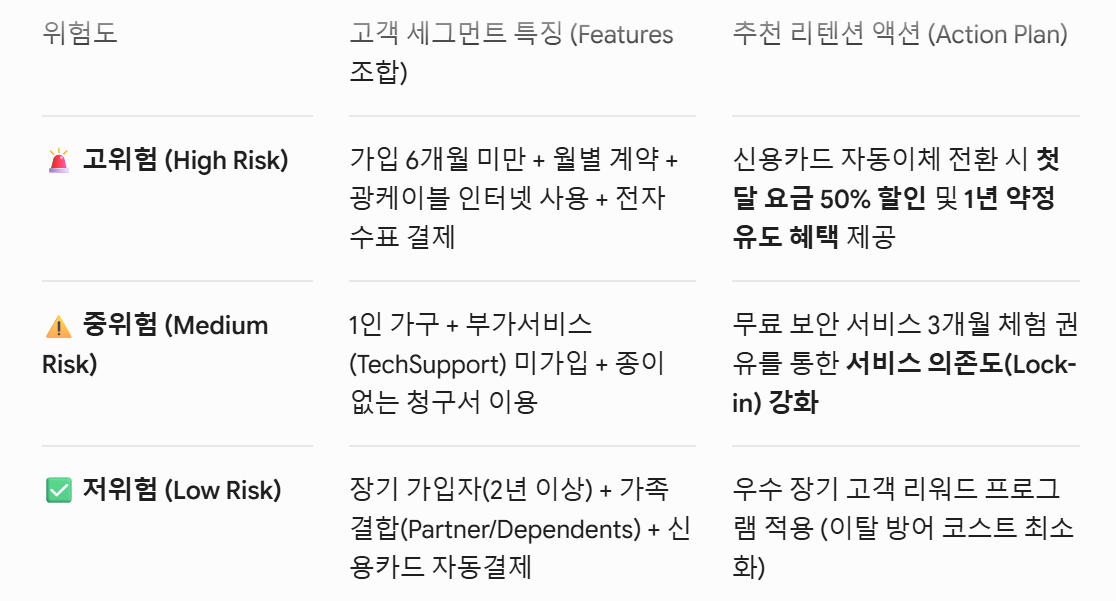

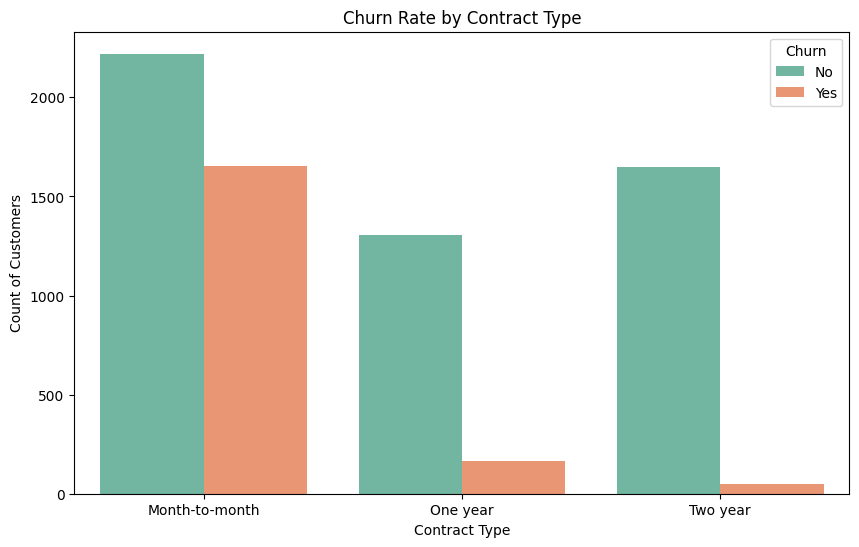

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 계약 형태(Contract)별 이탈(Churn) 비율 시각화
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count of Customers')
plt.show()

#1단계. EDA & 모델 탐지
1.통계적 데이터 분석 (EDA)

2.피처 엔지니어링 (Feature Engineering)

3.Baseline 모델 구축


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   PaperlessBilling                       7043 non-null   int64  
 8   MonthlyCharges                         7043 non-null   float64
 9   TotalCharges                           7043 non-null   float64
 10  Churn                                  7043 non-null   int64  
 11  Inte

In [10]:
import pandas as pd
import numpy as np

# 데이터 초기화 (기본 csv에서 다시 깨끗하게 로드)
df = pd.read_csv(real_filename)

# 1. customerID 열 제거 (이 열만 유일하게 삭제됩니다)
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# 2. TotalCharges 공백 제거 및 결측치 처리
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())


# ----------------------------------------------------
# 3. [수정] 모든 이진 변수 (Yes/No) -> 하나의 열에서 1과 0으로 변환
# ----------------------------------------------------
# 대상: Partner, Dependents, PhoneService, MultipleLines(아래서 따로 처리),
#       OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, PaperlessBilling, Churn
# 단, 일부 부가서비스의 'No internet service'는 'No'와 동일하게 0으로 처리하여 단순화합니다.

yes_no_mapping = {'Yes': 1, 'No': 0, 'No internet service': 0}

cols_to_map = [
    'Partner', 'Dependents', 'PhoneService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaperlessBilling', 'Churn'
]

for col in cols_to_map:
    if col in df.columns:
        df[col] = df[col].map(yes_no_mapping)

# gender: Female -> 0, Male -> 1
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

# MultipleLines: No -> 0, No phone service -> 1, Yes -> 2
if 'MultipleLines' in df.columns:
    df['MultipleLines'] = df['MultipleLines'].map({'No': 0, 'No phone service': 1, 'Yes': 2})


# ----------------------------------------------------
# 4. [요청 반영] 다중 범주형 변수 -> 열을 쪼개지 않고 '하나의 열' 안에서 숫자로 매핑
# ----------------------------------------------------

# (1) InternetService 매핑 (하나의 열 유지)
# DSL -> 0, Fiber optic -> 1, No -> 2
if 'InternetService' in df.columns:
    df['InternetService'] = df['InternetService'].map({'DSL': 0, 'Fiber optic': 1, 'No': 2})

# (2) Contract 매핑 (하나의 열 유지)
# Month-to-month -> 0, One year -> 1, Two year -> 2
if 'Contract' in df.columns:
    df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})

# (3) PaymentMethod 매핑 (하나의 열 유지)
# Electronic check -> 0, Mailed check -> 1, Bank transfer (automatic) -> 2, Credit card (automatic) -> 3
if 'PaymentMethod' in df.columns:
    df['PaymentMethod'] = df['PaymentMethod'].map({
        'Electronic check': 0,
        'Mailed check': 1,
        'Bank transfer (automatic)': 2,
        'Credit card (automatic)': 3
    })


# ====================================================
# 🔍 정확하게 수행되었는지 확인하는 검증 코드
# ====================================================
print("==== 1. 데이터프레임의 모든 열 이름 확인 (삭제된 열이 없는지 체크) ====")
print(df.columns.tolist())
# 총 20개의 열이 그대로 유지되어야 합니다. (customerID 제외)

print("\n==== 2. 질문하신 핵심 열들이 '하나의 열'에서 숫자로 변환되었는지 확인 ====")
print(f"Contract 고유값 (0, 1, 2 예상):", df['Contract'].unique())
print(f"PaymentMethod 고유값 (0, 1, 2, 3 예상):", df['PaymentMethod'].unique())
print(f"InternetService 고유값 (0, 1, 2 예상):", df['InternetService'].unique())
print(f"OnlineSecurity 고유값 (0, 1 예상):", df['OnlineSecurity'].unique())

print("\n==== 3. 최종 데이터프레임 전반부 확인 ====")
display(df.head(5))

==== 1. 데이터프레임의 모든 열 이름 확인 (삭제된 열이 없는지 체크) ====
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

==== 2. 질문하신 핵심 열들이 '하나의 열'에서 숫자로 변환되었는지 확인 ====
Contract 고유값 (0, 1, 2 예상): [0 1 2]
PaymentMethod 고유값 (0, 1, 2, 3 예상): [0 1 2 3]
InternetService 고유값 (0, 1, 2 예상): [0 1 2]
OnlineSecurity 고유값 (0, 1 예상): [0 1]

==== 3. 최종 데이터프레임 전반부 확인 ====


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,1,0,0,0,0,0,1,0,29.85,29.85,0
1,1,0,0,0,34,1,0,0,1,0,1,0,0,0,1,0,1,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,1,1,0,0,0,0,0,1,1,53.85,108.15,1
3,1,0,0,0,45,0,1,0,1,0,1,1,0,0,1,0,2,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,0,70.70,151.65,1


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


In [12]:
df.head((100))

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,1,0,0,0,0,0,1,0,29.85,29.85,0
1,1,0,0,0,34,1,0,0,1,0,1,0,0,0,1,0,1,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,1,1,0,0,0,0,0,1,1,53.85,108.15,1
3,1,0,0,0,45,0,1,0,1,0,1,1,0,0,1,0,2,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,0,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,0,0,0,12,1,2,1,1,0,0,0,0,0,0,1,0,78.95,927.35,1
96,1,0,1,1,71,1,2,0,1,1,0,1,0,0,1,1,3,66.85,4748.70,0
97,1,0,0,0,5,1,0,2,0,0,0,0,0,0,0,0,1,21.05,113.85,1
98,1,0,0,0,52,1,0,2,0,0,0,0,0,0,2,0,2,21.00,1107.20,0


In [14]:
# 다중 범주형 및 주요 매핑 정보 정의 (딕셔너리)
mapping_info = {
    "gender": {'Female': 0, 'Male': 1},
    "MultipleLines": {'No': 0, 'No phone service': 1, 'Yes': 2},
    "InternetService": {'DSL': 0, 'Fiber optic': 1, 'No': 2},
    "Contract": {'Month-to-month': 0, 'One year': 1, 'Two year': 2},
    "PaymentMethod": {
        'Electronic check': 0,
        'Mailed check': 1,
        'Bank transfer (automatic)': 2,
        'Credit card (automatic)': 3
    },
    "Yes/No 공동 적용 열 (Partner, Dependents, Churn 등)": {'Yes': 1, 'No': 0, 'No internet service': 0}
}

print("=" * 60)
print("=" * 60)

for column_name, mapping in mapping_info.items():
    print(f"\n▶ [열 이름: {column_name}]")
    print("-" * 40)
    for original_value, encoded_num in mapping.items():
        print(f"   • 기존 값: {original_value:<30} ➔  부여된 숫자: {encoded_num}")
    print("-" * 40)

print("\n" + "=" * 60)

print("=" * 60)


▶ [열 이름: gender]
----------------------------------------
   • 기존 값: Female                         ➔  부여된 숫자: 0
   • 기존 값: Male                           ➔  부여된 숫자: 1
----------------------------------------

▶ [열 이름: MultipleLines]
----------------------------------------
   • 기존 값: No                             ➔  부여된 숫자: 0
   • 기존 값: No phone service               ➔  부여된 숫자: 1
   • 기존 값: Yes                            ➔  부여된 숫자: 2
----------------------------------------

▶ [열 이름: InternetService]
----------------------------------------
   • 기존 값: DSL                            ➔  부여된 숫자: 0
   • 기존 값: Fiber optic                    ➔  부여된 숫자: 1
   • 기존 값: No                             ➔  부여된 숫자: 2
----------------------------------------

▶ [열 이름: Contract]
----------------------------------------
   • 기존 값: Month-to-month                 ➔  부여된 숫자: 0
   • 기존 값: One year                       ➔  부여된 숫자: 1
   • 기존 값: Two year                       ➔  부여된 숫자: 2
------------------

학습용 데이터 크기: (5634, 19)
검증용 데이터 크기: (1409, 19)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


📊 [Baseline: Logistic Regression 평가 결과]
• 정확도 (Accuracy)  : 0.8020
• 정밀도 (Precision) : 0.6471 -> 이탈이라고 예측한 사람 중 진짜 이탈한 비율
• 재현율 (Recall)    : 0.5588 -> 진짜 이탈한 사람 중 모델이 맞춘 비율 (★핵심 지표★)
• F1-Score          : 0.5997 -> 정밀도와 재현율의 조화 평균


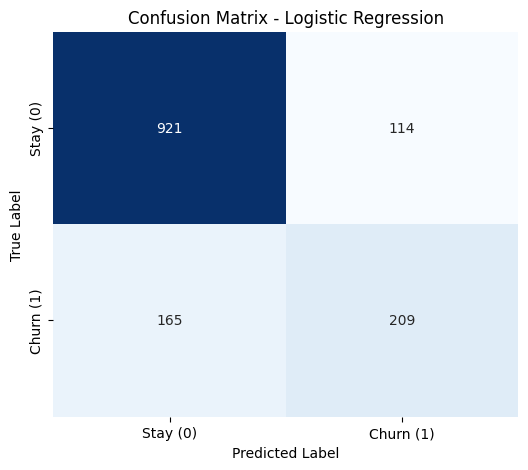

In [15]:
#Train_test_split and logistic regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. 독립변수(X)와 종속변수(y, Churn) 분리
# ----------------------------------------------------
# 예측 대상인 'Churn' 열을 y로 두고, 나머지를 X로 설정합니다.
X = df.drop(columns=['Churn'])
y = df['Churn']

# ----------------------------------------------------
# 2. train_test_split으로 데이터 쪼개기 (8:2)
# ----------------------------------------------------
# stratify=y 중요: 이탈률(26.54%) 비율을 학습용과 테스트용 데이터에 똑같은 비율로 쪼개줍니다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"학습용 데이터 크기: {X_train.shape}")
print(f"검증용 데이터 크기: {X_test.shape}\n")

# ----------------------------------------------------
# 3. Baseline 모델(Logistic Regression) 학습
# ----------------------------------------------------
# max_iter=1000: 수렴 안정성을 위해 반복 학습 횟수를 늘려줍니다.
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)

# ----------------------------------------------------
# 4. 모델 예측 및 평가
# ----------------------------------------------------
y_pred = model_lr.predict(X_test)

# 평가 지표 산출
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 50)
print("📊 [Baseline: Logistic Regression 평가 결과]")
print("=" * 50)
print(f"• 정확도 (Accuracy)  : {accuracy:.4f}")
print(f"• 정밀도 (Precision) : {precision:.4f} -> 이탈이라고 예측한 사람 중 진짜 이탈한 비율")
print(f"• 재현율 (Recall)    : {recall:.4f} -> 진짜 이탈한 사람 중 모델이 맞춘 비율 (★핵심 지표★)")
print(f"• F1-Score          : {f1:.4f} -> 정밀도와 재현율의 조화 평균")
print("=" * 50)

# ----------------------------------------------------
# 5. 오차 행렬 (Confusion Matrix) 시각화
# ----------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Stay (0)', 'Churn (1)'],
            yticklabels=['Stay (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



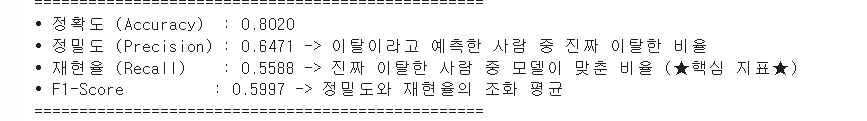

#Baseline : 재현율 , 정밀도 등 지표가 매우 낮게 나타남 -> random forest나 light bgm 으로 성능향상

# 데이터 추가 분석 ( appendix )
-Pearson Correlation ->  target: churn , -1~1 ( -1: 유지율이 높다  , +1 : 이탈율이 높다)

📊 [각 변수별 Churn(이탈률)과의 상관계수 순위]
• MonthlyCharges                 : +0.1934
• PaperlessBilling               : +0.1918
• SeniorCitizen                  : +0.1509
• StreamingTV                    : +0.0632
• StreamingMovies                : +0.0614
• MultipleLines                  : +0.0380
• PhoneService                   : +0.0119
• gender                         : -0.0086
• InternetService                : -0.0473
• DeviceProtection               : -0.0662
• OnlineBackup                   : -0.0823
• Partner                        : -0.1504
• Dependents                     : -0.1642
• TechSupport                    : -0.1647
• OnlineSecurity                 : -0.1712
• TotalCharges                   : -0.1990
• PaymentMethod                  : -0.2628
• tenure                         : -0.3522
• Contract                       : -0.3967


/tmp/ipykernel_1639/135398866.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_corr.values, y=churn_corr.index, palette=colors)


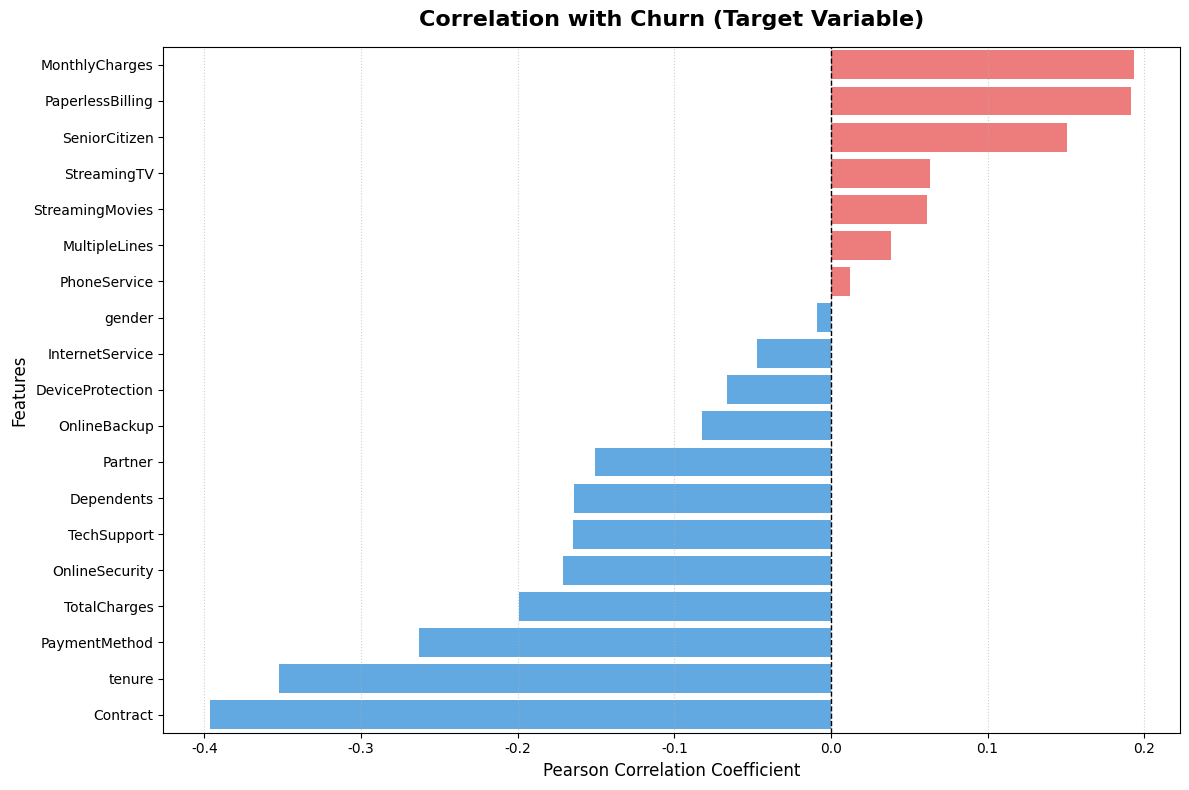

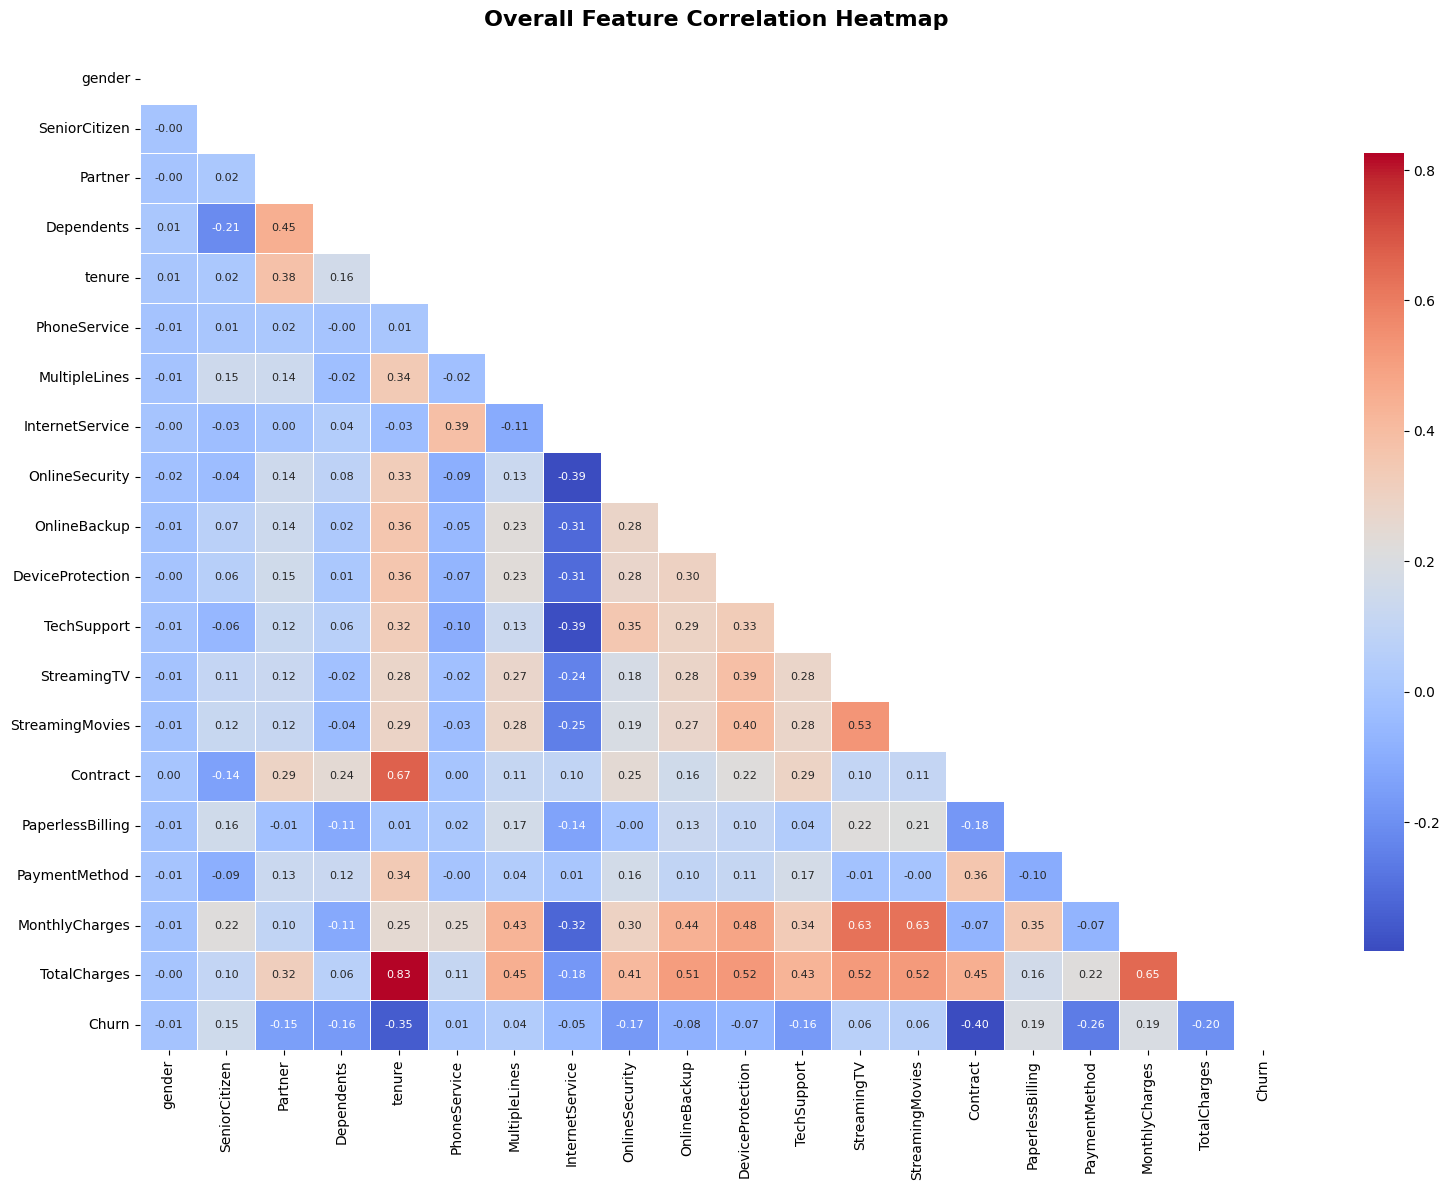

In [16]:
#각 지표가 이탈율에 미치는 영향 분석
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 모든 변수 간의 상관계수 행렬 계산
corr_matrix = df.corr()

# 2. 타겟 변수(Churn)와 다른 변수들 간의 상관계수만 추출 후 내림차순 정렬
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(ascending=False)

print("=" * 50)
print("📊 [각 변수별 Churn(이탈률)과의 상관계수 순위]")
print("=" * 50)
for col, val in churn_corr.items():
    print(f"• {col:<30} : {val:+.4f}")
print("=" * 50)

# 3. 시각화 세팅 (한글 깨짐 방지 폰트 및 마이너스 기호 설정)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 1: Churn 기준 상관계수 Barplot
plt.figure(figsize=(12, 8))
colors = ['#ff6b6b' if x > 0 else '#4dabf7' for x in churn_corr.values]
sns.barplot(x=churn_corr.values, y=churn_corr.index, palette=colors)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('Correlation with Churn (Target Variable)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# 시각화 2: 전체 변수 간의 Correlation Heatmap
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # 상삼각행렬 마스크 (중복 제거)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            mask=mask, linewidths=0.5, cbar_kws={"shrink": .8}, annot_kws={"size": 8})
plt.title('Overall Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

#Question : 총요금이 높을수록 이탈율이 높아져야되는거아닌가?

Ans: Tontal charge = tenure * Monthly charge

장기 고객의 특성: 아무리 월별 요금이 저렴하더라도 5년 동안 서비스를 유지한 고객-> 총요금 증가

초기 고객의 특성 : 월 요금이 비싸더라도 가입한지 별로 안된 초기 고객의 경우 총요금 작다

# 가입 기간 및 인터넷 서비스 별 '이탈위험' 분석

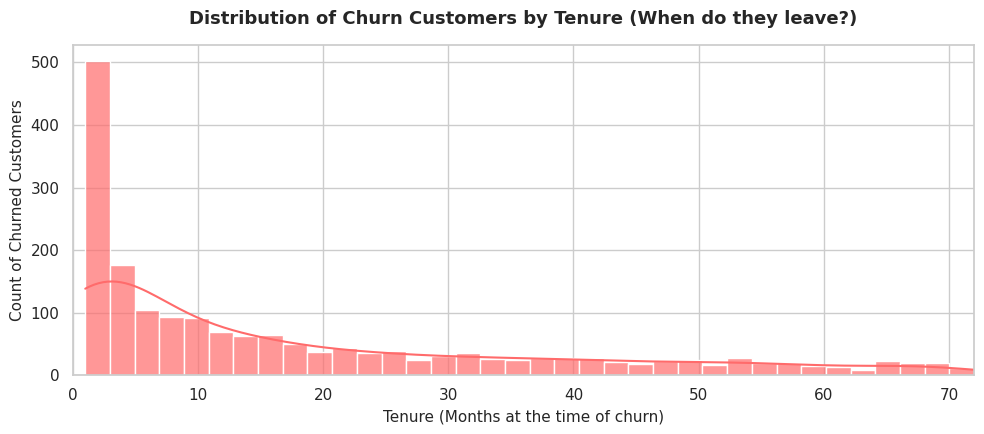

/tmp/ipykernel_1639/3557454444.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_churn_only, x='InternetService', palette='Reds_r', order=df_churn_only['InternetService'].value_counts().index)


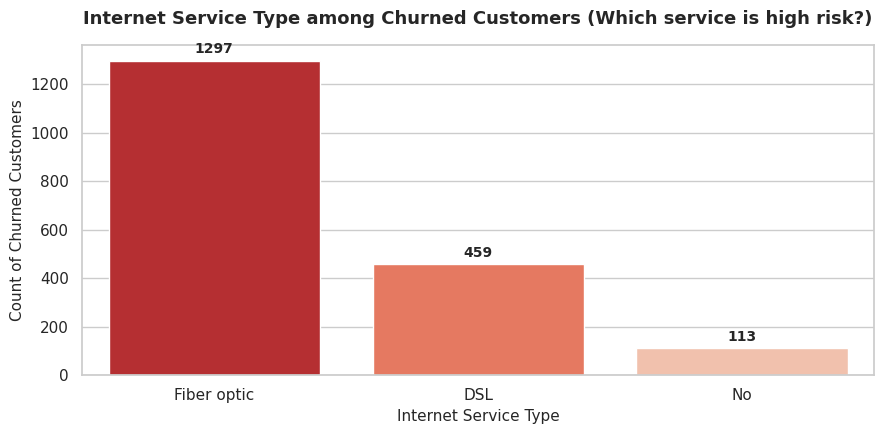

<Figure size 1000x450 with 0 Axes>

<Figure size 1000x450 with 0 Axes>

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 이탈 고객(Churn == Yes)만 필터링
try:
    df_analysis = pd.read_csv(real_filename)
except NameError:
    df_analysis = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 오직 이탈한 고객들만 추출
df_churn_only = df_analysis[df_analysis['Churn'] == 'Yes'].copy()

# 시각화 기본 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")


# ====================================================
# [그래프 1] 이탈 고객의 가입 기간(tenure) 분포 (언제 탈출하는가?)
# ====================================================
plt.figure(figsize=(10, 4.5))
# 이탈 고객이 몇 개월 차에 가장 많이 분포하는지 보여주는 히스토그램
sns.histplot(data=df_churn_only, x='tenure', bins=36, color='#ff6b6b', kde=True, alpha=0.7)
plt.title('Distribution of Churn Customers by Tenure (When do they leave?)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Tenure (Months at the time of churn)', fontsize=11)
plt.ylabel('Count of Churned Customers', fontsize=11)
plt.xlim(0, 72)
plt.tight_layout()
plt.show()


# ====================================================
# [그래프 2] 이탈 고객의 인터넷 서비스 유형 (어떤 상품 유저가 가장 많이 깨지는가?)
# ====================================================
plt.figure(figsize=(9, 4.5))
# 이탈 고객 중 각 인터넷 서비스가 차지하는 순수 대수(Count) 비교
sns.countplot(data=df_churn_only, x='InternetService', palette='Reds_r', order=df_churn_only['InternetService'].value_counts().index)
plt.title('Internet Service Type among Churned Customers (Which service is high risk?)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Internet Service Type', fontsize=11)
plt.ylabel('Count of Churned Customers', fontsize=11)

# 바 위에 실제 숫자 표시해주는 라벨링 추가
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


# ====================================================
# [그래/프 3] 이탈 고객의 부가서비스(Lock-in) 가입 개수 (몇 개 묶었을 때 이탈자가 많은가?)
# ====================================================
service_list = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_churn_only['Total_Services'] = df_churn_only[service_list].apply(lambda x: x == 'Yes').sum(axis=1)

plt.figure(figsize=(10, 4.5))
# 이

#결합상품 개수에 따른 이탈률 분석

📊 [결합 상품 가입 개수별 실제 이탈률 통계]
• 부가서비스 0개 가입 고객의 이탈률 : 21.41%
• 부가서비스 1개 가입 고객의 이탈률 : 45.76%
• 부가서비스 2개 가입 고객의 이탈률 : 35.82%
• 부가서비스 3개 가입 고객의 이탈률 : 27.37%
• 부가서비스 4개 가입 고객의 이탈률 : 22.30%
• 부가서비스 5개 가입 고객의 이탈률 : 12.43%
• 부가서비스 6개 가입 고객의 이탈률 : 5.28%


/tmp/ipykernel_1639/3413015164.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_rate_by_services, x='Total_Services', y='Churn_Rate_%', palette='coolwarm_r', alpha=0.85)


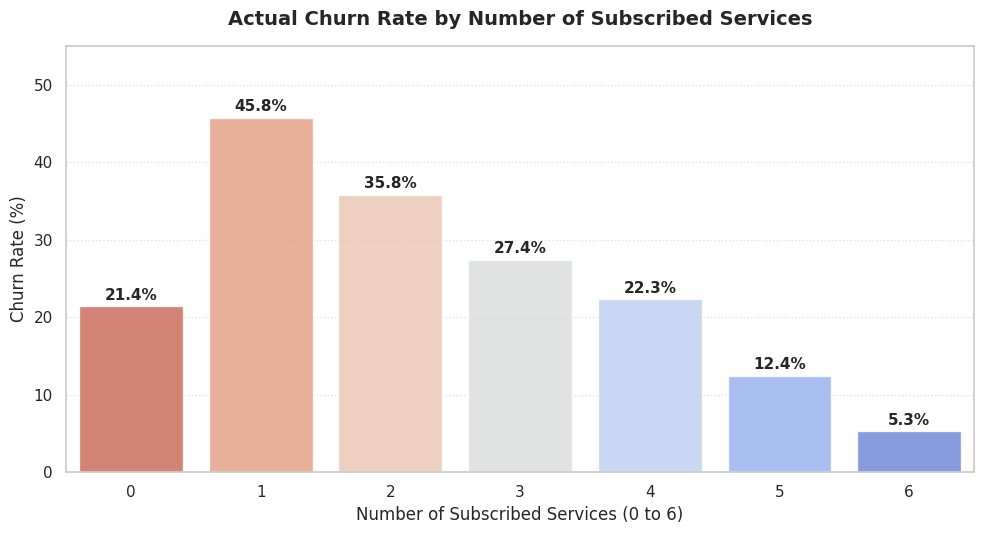

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 (기본 csv에서 다시 깨끗하게 로드)
try:
    df_lockin = pd.read_csv(real_filename)
except NameError:
    df_lockin = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Churn 변수를 연산을 위해 숫자형(1과 0)으로 변환
df_lockin['Churn_num'] = df_lockin['Churn'].map({'Yes': 1, 'No': 0})

# 2. 락인 효과를 측정할 6가지 부가서비스 리스트 정의
service_list = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# 고객별로 가입한('Yes') 부가서비스의 총 개수(0~6개)를 계산하여 새로운 열 생성
df_lockin['Total_Services'] = df_lockin[service_list].apply(lambda x: x == 'Yes').sum(axis=1)

# 3. 결합 상품 개수별 실제 이탈률(평균값 * 100) 데이터프레임 생성
churn_rate_by_services = df_lockin.groupby('Total_Services')['Churn_num'].mean().reset_index()
churn_rate_by_services['Churn_Rate_%'] = churn_rate_by_services['Churn_num'] * 100

print("=" * 50)
print("📊 [결합 상품 가입 개수별 실제 이탈률 통계]")
print("=" * 50)
for idx, row in churn_rate_by_services.iterrows():
    print(f"• 부가서비스 {int(row['Total_Services'])}개 가입 고객의 이탈률 : {row['Churn_Rate_%']:.2f}%")
print("=" * 50)

# 4. 시각화 (바차트)
plt.figure(figsize=(10, 5.5))
# 시각적으로 직관성을 높이기 위해 이탈률이 낮아질수록 연해지거나 짙어지는 컬러맵 적용
sns.barplot(data=churn_rate_by_services, x='Total_Services', y='Churn_Rate_%', palette='coolwarm_r', alpha=0.85)

# 바 그래프 위에 실제 이탈률 퍼센트(%) 라벨 표시
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=11, fontweight='bold')

plt.title('Actual Churn Rate by Number of Subscribed Services', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Subscribed Services (0 to 6)', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.ylim(0, 55) # 라벨이 잘리지 않도록 Y축 여유 공간 확보
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

고객이 이용하는 결합 상품의 개수가 높아질수록 이탈률이 지속적으로 줄어둠 , 특히 3개 이상일 때 30% 이하로 3개 이상으로 패키징할 때 좋은 전략이 될 수 있을 것이라 생각함

#2단계. Segmentation & modeling
1. 고객 segmentation - k_means clustering or DBSCAN
2. Decision Tree , Random Forest (정보이득 , 지니 불순도)



#3단계. LightGBM 모델 튜빙 및 모델 평가

    1. Light GBM & Hyperparameter tuning  : Leaf wise 성장 방식 ,(max_depth, learning rate , num_leaves)
    
    2.불균형 데이터 처리 및 recall(최적화) : SMOTE같은 오버 샘플링 기법 ,False negative 줄이기

    3.SHAP 분석 및 리텐션 전략
    - Shapely additive exPlanations
    -리텐션 전략 (ex) 약정 기간이 끝난 고객에게 결합 할인 혜택 제안하는 자동화 스크립트 작성
    